# E3 — Teknon-only experiment: QRS + clinical data

Companion to:

* `E3_qrs_only_full_pool_experiment_extended.ipynb` (PCA, all sources)
* `E3_qrs_binned_interpretable_experiment.ipynb` (binned QRS, all sources)

**What is different here.** We restrict ourselves to the **Teknon cohort only** — both training and test — so that we can use the **patient-level clinical data** that is available exclusively for Teknon (Age, Sex, hypertension, V3 amplitude, precordial transition). This replicates *Experiments B and C* from Bocanegra-Pérez et al. (2024), where the best models reached 89% accuracy and 86% balanced accuracy on this same cohort.

Three families of models are compared:

| Family | Inputs | Paper analogue |
|---|---|---|
| **A — QRS only** | 120 binned QRS features (12 leads × 10 bins) | Experiment A.1 (Teknon only) |
| **B — Clinical only** | Age, Sex, HTA, V3 amplitude, precordial-transition vector | **Experiment B.4** (paper's headline 89%/86%) |
| **C — Combined** | C.1: clinical + out-of-fold QRS prediction (stacking)<br>C.2: clinical + out-of-fold QRS probability (stacking)<br>C.3: clinical + 120 binned QRS features (concatenation) | **Experiment C** |

Binary task: `0 = LVOT`, `1 = RVOT`.

**Key methodological notes**

* The Teknon training pool has **143 patients**; the test set has **37 patients** (`patient_144` → `patient_180`, the official held-out split).
* For the stacked models (C.1, C.2) we use `cross_val_predict` so that the QRS-derived feature on each training sample is computed by a model that **did not see that sample during fit** — this avoids the leakage that an in-sample prediction would introduce.
* V3 amplitude is taken from the **raw pkl signals (in mV)**, not from the z-score-normalised `.npy`, because the latter has the absolute amplitude information removed.
* Model selection is based exclusively on **internal cross-validation balanced accuracy**; the test set is touched only once at the end.


## 1. Imports & config

In [1]:
import os
# If you are running locally, uncomment and adapt:
# os.chdir(r"c:\Users\jaime\Downloads\corrected_split_pool\corrected_split_pool")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import joblib
import time

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
)

try:
    import shap
    SHAP_AVAILABLE = True
    print(f"SHAP available, version {shap.__version__}")
except Exception as e:
    SHAP_AVAILABLE = False
    print(f"SHAP is not installed ({e!s}). The notebook will still run; SHAP section will be skipped.")

RANDOM_STATE = 42
N_FOLDS = 5
N_BINS = 10

LEAD_NAMES = ["I", "II", "III", "aVR", "aVL", "aVF",
              "V1", "V2", "V3", "V4", "V5", "V6"]
PRECORDIAL_LEADS = ["V1", "V2", "V3", "V4", "V5", "V6"]
CLASS_NAMES = ["LVOT", "RVOT"]

np.random.seed(RANDOM_STATE)

from pathlib import Path

def find_file(filename):
    """
    Finds data files whether the notebook is run from:
    - the main new_data folder, or
    - one of its subfolders (CNN / binned / teknon_only).
    """
    candidates = [
        Path(".") / filename,
        Path("..") / filename,
    ]
    for p in candidates:
        if p.exists():
            return str(p)
    raise FileNotFoundError(
        f"Could not find {filename}. Put it in the notebook folder or in the parent new_data folder."
    )


SHAP available, version 0.44.1


## 2. Load data and isolate the Teknon-only training pool

The shared `X_train_pool_corrected.npy` mixes four sources (Sims, Database, Teknon, CARTO). Clinical variables (age, sex, HTA, …) only exist for Teknon, so we filter the pool to Teknon rows.

In [2]:
# 12-lead × 200-sample aligned QRS complexes (z-score-normalised)
X_train_pool = np.load(find_file("X_train_pool_binary_corrected_clean.npy"))
y_train_pool = np.load(find_file("y_train_pool_binary_corrected_clean.npy"))

X_test = np.load(find_file("X_teknon_final_test_binary_corrected_clean.npy"))
y_test = np.load(find_file("y_teknon_final_test_binary_corrected_clean.npy"))

info_train = pd.read_csv(find_file("info_train_pool_binary_corrected_clean.csv"))
info_test  = pd.read_csv(find_file("info_teknon_final_test_binary_corrected_clean.csv"))

# Raw pkl (variable-length original signals + clinical metadata, 181 patients)
with open(find_file("full_data_7class.pkl"), "rb") as f:
    pkl = pickle.load(f)

# --- Filter the training pool to Teknon rows ---
tek_mask = info_train["dataset"].astype(str).str.lower() == "teknon"
tek_idx_in_pool = np.where(tek_mask.values)[0]
X_train_tek = X_train_pool[tek_idx_in_pool]
y_train_tek = y_train_pool[tek_idx_in_pool]
info_train_tek = info_train.iloc[tek_idx_in_pool].reset_index(drop=True)

# patient_index is the row in the pkl dictionary (patient_NNN ↔ pkl[NNN])
train_patient_ids = info_train_tek["patient_index"].astype(int).to_numpy()
test_patient_ids  = info_test["patient_index"].astype(int).to_numpy()

print(f"Teknon train: {X_train_tek.shape}, labels: {np.unique(y_train_tek, return_counts=True)}")
print(f"Teknon test : {X_test.shape}, labels: {np.unique(y_test, return_counts=True)}")
print(f"Train patient_index range: {train_patient_ids.min()}..{train_patient_ids.max()}")
print(f"Test  patient_index range: {test_patient_ids.min()}..{test_patient_ids.max()}")
print(f"pkl total entries: {len(pkl['Age'])}")


Teknon train: (137, 12, 200), labels: (array([0, 1]), array([54, 83], dtype=int64))
Teknon test : (36, 12, 200), labels: (array([0, 1]), array([18, 18], dtype=int64))
Train patient_index range: 0..144
Test  patient_index range: 145..180
pkl total entries: 181


## 3. Qualitative inspection — raw QRS overlays per class

Before any feature engineering, we look at the **raw signal** restricted to the Teknon cohort that the model will actually train on. For each of the 12 leads we plot the mean QRS (± 1 SD) of LVOT vs. RVOT side by side.

* The shaded grey band marks the **50%–80% segment** of the QRS — the R/S transition zone that Bocanegra-Pérez et al. (2024, Figure 4) identify as the most discriminative region.
* Dotted vertical lines mark the **10% bin boundaries** we will use in §5 (binned features).

**Why this matters for the talk.** This is the *qualitative* end of the interpretability spectrum the rubric asks for — before SHAP, before permutation importance, just two average waveforms. If LVOT and RVOT separate visibly in V2/V3/V4 around the 60–70% mark, the quantitative results in §11–§13 will confirm the same regions — and that consistency is itself a finding.

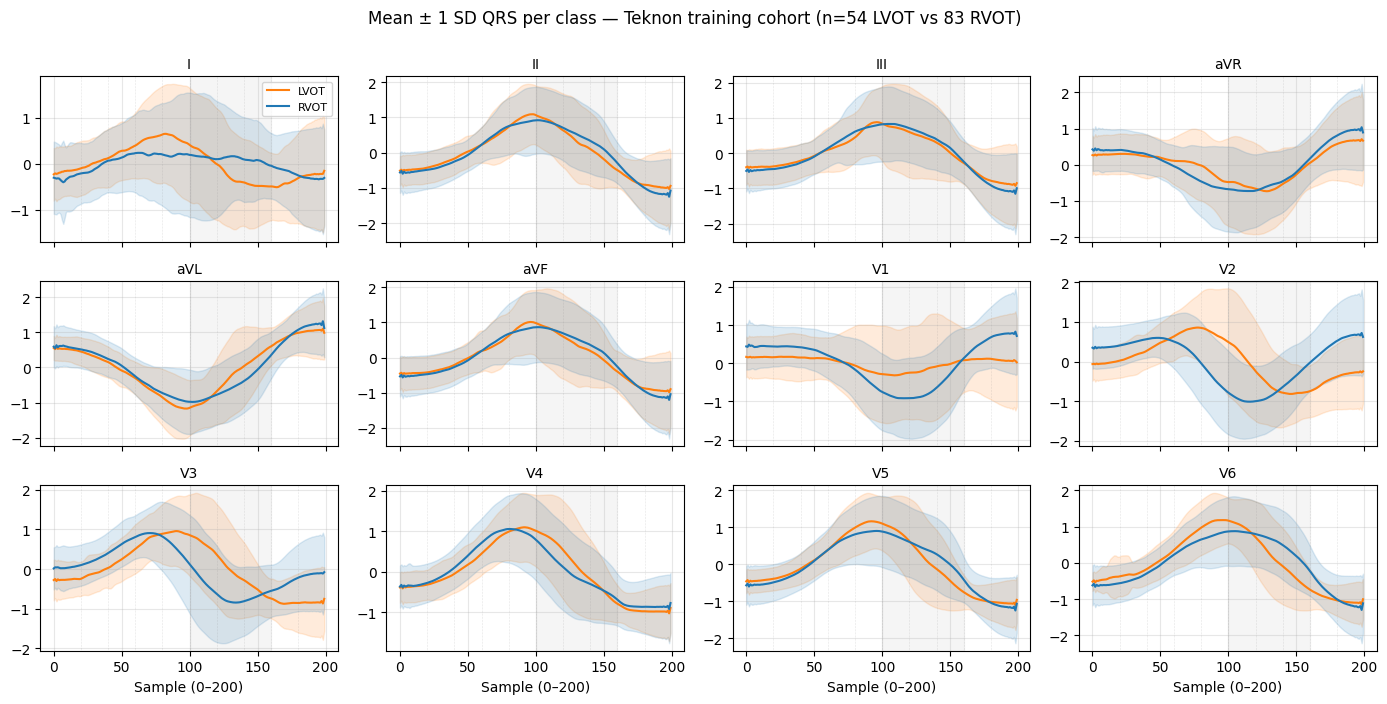

In [3]:
def plot_qualitative_qrs(X, y, lead_names=LEAD_NAMES,
                          highlight_region=(50, 80),
                          title="Mean ± 1 SD QRS per class"):
    """3x4 grid of leads, mean signal of LVOT vs RVOT with SD bands."""
    n_timepoints = X.shape[2]
    fig, axes = plt.subplots(3, 4, figsize=(14, 7), sharex=True)
    t = np.arange(n_timepoints)
    pct_to_idx = lambda p: int(round(p * n_timepoints / 100))

    for li, (ax, lead) in enumerate(zip(axes.flat, lead_names)):
        for cls, color, name in [(0, "C1", "LVOT"), (1, "C0", "RVOT")]:
            mask = y == cls
            m = X[mask, li].mean(0)
            s = X[mask, li].std(0)
            ax.plot(t, m, color=color, lw=1.5, label=name)
            ax.fill_between(t, m - s, m + s, color=color, alpha=0.15)
        if highlight_region is not None:
            ax.axvspan(pct_to_idx(highlight_region[0]),
                       pct_to_idx(highlight_region[1]),
                       color="grey", alpha=0.08)
        for pct in range(10, 100, 10):
            ax.axvline(pct_to_idx(pct), color="grey", lw=0.4, ls=":", alpha=0.4)
        ax.set_title(lead, fontsize=10)
        ax.grid(alpha=0.3)
    axes[0, 0].legend(loc="upper right", fontsize=8)
    for ax in axes[-1, :]:
        ax.set_xlabel(f"Sample (0–{n_timepoints})")
    plt.suptitle(title, y=1.00, fontsize=12)
    plt.tight_layout()
    return fig


fig = plot_qualitative_qrs(
    X_train_tek, y_train_tek,
    title=f"Mean ± 1 SD QRS per class — Teknon training cohort "
          f"(n={(y_train_tek==0).sum()} LVOT vs {(y_train_tek==1).sum()} RVOT)"
)
plt.savefig("fig_qualitative_qrs_teknon.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Build the clinical-feature table

We replicate the **paper's Scenario B.4** feature set:

* `Age_norm` — Age / 100 (median-imputed if missing)
* `Sex_bin` — 1 if Male, 0 if Female (mode-imputed)
* `HTA_bin` — 1 if Yes, 0 if No (mode-imputed)
* `V3_amp` — V3 peak-to-peak amplitude in mV, computed from the **raw** pkl signal (max − min over the 2500-sample window). This is the actual mV amplitude the cardiologist would see — the normalised `.npy` would lose it.
* `vPVC_V1`, `vPVC_V2`, …, `vPVC_V6` — one-hot of the precordial transition lead, as in the paper's vPTC representation.

These are the 4 + 6 = **10 clinical/ECG-derived features**.

In [4]:
def _to_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

def build_clinical_features(patient_ids, pkl):
    """
    For each patient_id, build a row of clinical/ECG-derived features.

    Parameters
    ----------
    patient_ids : array-like of int
        Indices into the pkl dictionary (patient_NNN ↔ pkl[NNN]).
    pkl : dict
        Loaded from full_data_7class.pkl.

    Returns
    -------
    df : pd.DataFrame with one row per patient_id, 10 columns:
        Age_norm, Sex_bin, HTA_bin, V3_amp, vPVC_V1..vPVC_V6
    """
    rows = []
    for pid in patient_ids:
        age = _to_float(pkl["Age"][pid])
        sex = pkl["Sex"][pid]
        hta = pkl["HTA"][pid]
        pvc = pkl["PVC_transition"][pid]

        # V3 amplitude from raw pkl signal (mV, peak-to-peak)
        v3_sig = np.asarray(pkl["V3"][pid], dtype=float)
        v3_amp = float(v3_sig.max() - v3_sig.min()) if v3_sig.size else np.nan

        row = {
            "patient_index": int(pid),
            "Age_norm": age / 100.0 if not np.isnan(age) else np.nan,
            "Sex_bin": 1.0 if isinstance(sex, str) and sex.lower() == "male" else (
                       0.0 if isinstance(sex, str) and sex.lower() == "female" else np.nan),
            "HTA_bin": 1.0 if isinstance(hta, str) and hta.lower() == "yes" else (
                       0.0 if isinstance(hta, str) and hta.lower() == "no"  else np.nan),
            "V3_amp": v3_amp,
        }
        # One-hot precordial transition (V1..V6)
        for lead in PRECORDIAL_LEADS:
            row[f"vPVC_{lead}"] = 1.0 if pvc == lead else 0.0
        # If transition is missing (NaN string or None), leave the one-hot all-zero
        # — that's a benign code for "unknown" that the model can pick up.
        rows.append(row)
    return pd.DataFrame(rows)


clin_train_df = build_clinical_features(train_patient_ids, pkl)
clin_test_df  = build_clinical_features(test_patient_ids,  pkl)

print("Clinical train table:", clin_train_df.shape)
print("Clinical test  table:", clin_test_df.shape)
print("\nMissing values BEFORE imputation:")
print(clin_train_df.drop(columns=["patient_index"]).isna().sum())

CLIN_COLS = ["Age_norm", "Sex_bin", "HTA_bin", "V3_amp"] + [f"vPVC_{l}" for l in PRECORDIAL_LEADS]
print("\nFeature columns:", CLIN_COLS)
clin_train_df.head()


Clinical train table: (137, 11)
Clinical test  table: (36, 11)

Missing values BEFORE imputation:
Age_norm    2
Sex_bin     1
HTA_bin     4
V3_amp      0
vPVC_V1     0
vPVC_V2     0
vPVC_V3     0
vPVC_V4     0
vPVC_V5     0
vPVC_V6     0
dtype: int64

Feature columns: ['Age_norm', 'Sex_bin', 'HTA_bin', 'V3_amp', 'vPVC_V1', 'vPVC_V2', 'vPVC_V3', 'vPVC_V4', 'vPVC_V5', 'vPVC_V6']


,patient_index,Age_norm,Sex_bin,HTA_bin,V3_amp,vPVC_V1,vPVC_V2,vPVC_V3,vPVC_V4,vPVC_V5,vPVC_V6
0,0,0.61,0.0,NaN,2.475,1.0,0.0,0.0,0.0,0.0,0.0
1,1,0.52,0.0,0.0,1.581,0.0,0.0,1.0,0.0,0.0,0.0
2,2,0.69,0.0,0.0,1.260,0.0,0.0,1.0,0.0,0.0,0.0
3,3,0.66,0.0,0.0,1.587,0.0,0.0,0.0,1.0,0.0,0.0
4,4,0.46,0.0,1.0,1.053,0.0,0.0,1.0,0.0,0.0,0.0


In [5]:
# Impute missing values: median (continuous) and most_frequent (binary).
# Fit on TRAIN only, apply to test.
continuous_cols = ["Age_norm", "V3_amp"]
binary_cols     = ["Sex_bin", "HTA_bin"]  # vPVC_* already 0/1 (zero = unknown is fine)

imp_cont = SimpleImputer(strategy="median").fit(clin_train_df[continuous_cols])
imp_bin  = SimpleImputer(strategy="most_frequent").fit(clin_train_df[binary_cols])

clin_train_df[continuous_cols] = imp_cont.transform(clin_train_df[continuous_cols])
clin_test_df[continuous_cols]  = imp_cont.transform(clin_test_df[continuous_cols])
clin_train_df[binary_cols]     = imp_bin.transform(clin_train_df[binary_cols])
clin_test_df[binary_cols]      = imp_bin.transform(clin_test_df[binary_cols])

X_clin_train = clin_train_df[CLIN_COLS].to_numpy(dtype=np.float32)
X_clin_test  = clin_test_df[CLIN_COLS].to_numpy(dtype=np.float32)

print("Missing values AFTER imputation:")
print(clin_train_df[CLIN_COLS].isna().sum().sum(), "in train,",
      clin_test_df[CLIN_COLS].isna().sum().sum(), "in test")
print("\nX_clin_train:", X_clin_train.shape, "  X_clin_test:", X_clin_test.shape)
print("\nDescribe (train):")
clin_train_df[CLIN_COLS].describe().round(3)


Missing values AFTER imputation:
0 in train, 0 in test

X_clin_train: (137, 10)   X_clin_test: (36, 10)

Describe (train):


,Age_norm,Sex_bin,HTA_bin,V3_amp,vPVC_V1,vPVC_V2,vPVC_V3,vPVC_V4,vPVC_V5,vPVC_V6
count,137.000,137.000,137.000,137.000,137.000,137.000,137.000,137.000,137.000,137.000
mean,0.566,0.526,0.343,2.460,0.161,0.161,0.321,0.204,0.073,0.051
std,0.158,0.501,0.476,0.970,0.368,0.368,0.469,0.405,0.261,0.221
min,0.150,0.000,0.000,0.627,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.440,0.000,0.000,1.719,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.590,1.000,0.000,2.268,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.680,1.000,1.000,2.943,0.000,0.000,1.000,0.000,0.000,0.000
max,0.880,1.000,1.000,5.769,1.000,1.000,1.000,1.000,1.000,1.000


## 5. Binned QRS features (12 leads × 10 bins = 120)

Same builder as in `E3_qrs_binned_interpretable_experiment.ipynb`. Each feature has the form `LEAD_<start>_<end>` (e.g. `V3_60_70`), so importance scores map back to a specific lead and a specific portion of the QRS complex.

In [6]:
def create_binned_qrs_features(X, lead_names=LEAD_NAMES, n_bins=N_BINS, aggregation="mean"):
    """Reshape (n, 12, 200) → (n, 12*n_bins) with interpretable bin names."""
    n_samples, n_leads, n_timepoints = X.shape
    edges = np.linspace(0, n_timepoints, n_bins + 1, dtype=int)
    pct = np.linspace(0, 100, n_bins + 1, dtype=int)
    X_binned = np.zeros((n_samples, n_leads * n_bins), dtype=np.float32)
    names = []
    for li, lead in enumerate(lead_names):
        for bi in range(n_bins):
            seg = X[:, li, edges[bi]:edges[bi+1]]
            X_binned[:, li*n_bins + bi] = seg.mean(axis=1) if aggregation == "mean" else \
                                          np.max(np.abs(seg), axis=1)
            names.append(f"{lead}_{pct[bi]}_{pct[bi+1]}")
    return X_binned, names


X_qrs_train, qrs_feature_names = create_binned_qrs_features(X_train_tek)
X_qrs_test,  _                  = create_binned_qrs_features(X_test)

print("Binned QRS train:", X_qrs_train.shape)
print("Binned QRS test :", X_qrs_test.shape)
print("First 6 / last 6 feature names:", qrs_feature_names[:6], "...", qrs_feature_names[-6:])


Binned QRS train: (137, 120)
Binned QRS test : (36, 120)
First 6 / last 6 feature names: ['I_0_10', 'I_10_20', 'I_20_30', 'I_30_40', 'I_40_50', 'I_50_60'] ... ['V6_40_50', 'V6_50_60', 'V6_60_70', 'V6_70_80', 'V6_80_90', 'V6_90_100']


## 6. Model zoo

Same five base models as in the binned experiment. `LinearSVC` is wrapped in `CalibratedClassifierCV` so that every model exposes `predict_proba` — needed for AUC, stacking and SHAP.

In [7]:
def build_models(random_state=RANDOM_STATE):
    models = {}
    models["LogReg"] = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced",
                                   random_state=random_state)),
    ])
    models["LinearSVM"] = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", CalibratedClassifierCV(
            estimator=LinearSVC(class_weight="balanced", max_iter=5000,
                                random_state=random_state),
            cv=3)),
    ])
    models["RandomForest"] = RandomForestClassifier(
        n_estimators=500, class_weight="balanced", random_state=random_state, n_jobs=-1)
    models["GradientBoosting"] = GradientBoostingClassifier(
        n_estimators=300, max_depth=3, random_state=random_state)
    models["MLP"] = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=2000,
                              early_stopping=True, random_state=random_state)),
    ])
    return models

# A single fold-splitter object reused everywhere (deterministic across experiments)
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)


def cv_evaluate(model, X, y, splitter=skf):
    """Per-fold metrics for one model on (X, y) under a fixed splitter."""
    rows = []
    for fold_idx, (tr, va) in enumerate(splitter.split(X, y)):
        est = clone(model)
        est.fit(X[tr], y[tr])
        y_pred = est.predict(X[va])
        if hasattr(est, "predict_proba"):
            y_score = est.predict_proba(X[va])[:, 1]
        elif hasattr(est, "decision_function"):
            y_score = est.decision_function(X[va])
        else:
            y_score = y_pred
        rows.append({
            "fold": fold_idx,
            "accuracy": accuracy_score(y[va], y_pred),
            "balanced_accuracy": balanced_accuracy_score(y[va], y_pred),
            "macro_f1": f1_score(y[va], y_pred, average="macro"),
            "roc_auc": roc_auc_score(y[va], y_score),
        })
    return pd.DataFrame(rows)


## 7. Cross-validation — Experiment A (QRS only, Teknon)

Same 120 binned QRS features, but the pool is now restricted to the 143 Teknon patients. This is the closest analogue to the paper's Scenario A.1.

In [8]:
def aggregate_cv(folds_df, model_name, experiment):
    a = folds_df.drop(columns=["fold"]).agg(["mean", "std"])
    return {
        "experiment": experiment,
        "model": model_name,
        "accuracy_mean":          a.loc["mean", "accuracy"],
        "accuracy_std":           a.loc["std",  "accuracy"],
        "balanced_accuracy_mean": a.loc["mean", "balanced_accuracy"],
        "balanced_accuracy_std":  a.loc["std",  "balanced_accuracy"],
        "macro_f1_mean":          a.loc["mean", "macro_f1"],
        "macro_f1_std":           a.loc["std",  "macro_f1"],
        "roc_auc_mean":           a.loc["mean", "roc_auc"],
        "roc_auc_std":            a.loc["std",  "roc_auc"],
    }


cv_rows_A = []
for name, m in build_models().items():
    folds = cv_evaluate(m, X_qrs_train, y_train_tek)
    cv_rows_A.append(aggregate_cv(folds, name, "A_QRS_only"))
    print(f"  A {name:18s} bal_acc = {folds['balanced_accuracy'].mean():.3f} "
          f"± {folds['balanced_accuracy'].std():.3f}")

cv_A_df = pd.DataFrame(cv_rows_A).sort_values("balanced_accuracy_mean", ascending=False)
cv_A_df.round(3)


  A LogReg             bal_acc = 0.696 ± 0.043
  A LinearSVM          bal_acc = 0.629 ± 0.084
  A RandomForest       bal_acc = 0.719 ± 0.027
  A GradientBoosting   bal_acc = 0.652 ± 0.038
  A MLP                bal_acc = 0.645 ± 0.128


,experiment,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,roc_auc_mean,roc_auc_std
2,A_QRS_only,RandomForest,0.745,0.035,0.719,0.027,0.723,0.031,0.792,0.078
0,A_QRS_only,LogReg,0.708,0.030,0.696,0.043,0.690,0.038,0.698,0.095
3,A_QRS_only,GradientBoosting,0.671,0.027,0.652,0.038,0.648,0.037,0.742,0.067
4,A_QRS_only,MLP,0.686,0.107,0.645,0.128,0.632,0.151,0.767,0.130
1,A_QRS_only,LinearSVM,0.685,0.070,0.629,0.084,0.614,0.115,0.738,0.105


In [9]:
# Pick the best A model on CV — we'll use it to generate the stacking feature for C.1 and C.2
best_A_model_name = cv_A_df.iloc[0]["model"]
print(f"Best A model (CV balanced_acc): {best_A_model_name}")
print(f"  bal_acc = {cv_A_df.iloc[0]['balanced_accuracy_mean']:.3f} "
      f"± {cv_A_df.iloc[0]['balanced_accuracy_std']:.3f}")


Best A model (CV balanced_acc): RandomForest
  bal_acc = 0.719 ± 0.027


## 8. Cross-validation — Experiment B (clinical only)

Features: `Age_norm, Sex_bin, HTA_bin, V3_amp, vPVC_V1..vPVC_V6` — 10 features total.

In the paper, this scenario (B.4) achieved **89% accuracy / 86% balanced accuracy** with XGBoost on the same Teknon cohort.

In [10]:
cv_rows_B = []
for name, m in build_models().items():
    folds = cv_evaluate(m, X_clin_train, y_train_tek)
    cv_rows_B.append(aggregate_cv(folds, name, "B_clinical_only"))
    print(f"  B {name:18s} bal_acc = {folds['balanced_accuracy'].mean():.3f} "
          f"± {folds['balanced_accuracy'].std():.3f}")

cv_B_df = pd.DataFrame(cv_rows_B).sort_values("balanced_accuracy_mean", ascending=False)
cv_B_df.round(3)


  B LogReg             bal_acc = 0.754 ± 0.030
  B LinearSVM          bal_acc = 0.728 ± 0.036
  B RandomForest       bal_acc = 0.734 ± 0.051
  B GradientBoosting   bal_acc = 0.706 ± 0.058
  B MLP                bal_acc = 0.536 ± 0.059


,experiment,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,roc_auc_mean,roc_auc_std
0,B_clinical_only,LogReg,0.752,0.035,0.754,0.030,0.746,0.032,0.840,0.083
2,B_clinical_only,RandomForest,0.744,0.052,0.734,0.051,0.733,0.054,0.735,0.061
1,B_clinical_only,LinearSVM,0.752,0.033,0.728,0.036,0.730,0.038,0.841,0.087
3,B_clinical_only,GradientBoosting,0.722,0.049,0.706,0.058,0.706,0.058,0.734,0.054
4,B_clinical_only,MLP,0.635,0.040,0.536,0.059,0.444,0.102,0.716,0.142


## 9. Cross-validation — Experiment C (combined: clinical + QRS probability)

We keep a single combined scenario, **C2 = clinical features + QRS probability**, and compare
it against the clinical-only model (B). The QRS probability is generated out-of-fold so there
is no leakage. The scientific question is simply: *does adding the QRS morphology signal
improve over the clinical features alone?*


In [11]:
best_A_model = build_models()[best_A_model_name]

# --- Out-of-fold (OOF) QRS probabilities for the Teknon training patients ---
# CRITICAL: for each training patient, the QRS probability must come from a model that did
# NOT see that patient. cross_val_predict guarantees this (no leakage into the combined model).
print(f"Computing OOF probabilities from {best_A_model_name} via cross_val_predict...")
oof_proba = cross_val_predict(
    clone(best_A_model), X_qrs_train, y_train_tek,
    cv=skf, method="predict_proba", n_jobs=1,
)[:, 1]  # P(class = 1 = RVOT)
oof_pred = (oof_proba >= 0.5).astype(int)
print(f"OOF agreement with y: {(oof_pred == y_train_tek).mean():.3f}")

# Time-boxed: keep only TWO scenarios -> B (clinical only) and C2 (clinical + QRS probability).
# C2 is preferred over the binary-prediction variant because the probability carries more
# information (P(RVOT)=0.51 vs 0.99 differ, but both collapse to '1' in the binary version).
X_C2_train = np.hstack([X_clin_train, oof_proba.reshape(-1, 1).astype(np.float32)])
print("C2 train shape:", X_C2_train.shape)


Computing OOF probabilities from RandomForest via cross_val_predict...
OOF agreement with y: 0.745
C2 train shape: (137, 11)


In [12]:
# Cross-validate the single combined scenario we keep: C2 (clinical + QRS probability).
# All 137 training rows are Teknon, so this CV is already entirely in the target domain.
cv_rows_C = []
for c_name, X_c in [("C2_clin_plus_proba", X_C2_train)]:
    print(f"--- {c_name} ---")
    for name, m in build_models().items():
        folds = cv_evaluate(m, X_c, y_train_tek)
        cv_rows_C.append(aggregate_cv(folds, name, c_name))
        print(f"  {c_name} / {name:18s} bal_acc = {folds['balanced_accuracy'].mean():.3f} "
              f"\u00b1 {folds['balanced_accuracy'].std():.3f}")

cv_C_df = pd.DataFrame(cv_rows_C).sort_values("balanced_accuracy_mean", ascending=False)
cv_C_df.round(3)


--- C2_clin_plus_proba ---
  C2_clin_plus_proba / LogReg             bal_acc = 0.742 ± 0.041
  C2_clin_plus_proba / LinearSVM          bal_acc = 0.716 ± 0.029
  C2_clin_plus_proba / RandomForest       bal_acc = 0.695 ± 0.082
  C2_clin_plus_proba / GradientBoosting   bal_acc = 0.707 ± 0.045
  C2_clin_plus_proba / MLP                bal_acc = 0.695 ± 0.065


,experiment,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,roc_auc_mean,roc_auc_std
0,C2_clin_plus_proba,LogReg,0.738,0.050,0.742,0.041,0.731,0.047,0.826,0.081
1,C2_clin_plus_proba,LinearSVM,0.737,0.029,0.716,0.029,0.717,0.031,0.824,0.080
3,C2_clin_plus_proba,GradientBoosting,0.723,0.040,0.707,0.045,0.707,0.045,0.753,0.038
4,C2_clin_plus_proba,MLP,0.694,0.064,0.695,0.065,0.685,0.062,0.757,0.084
2,C2_clin_plus_proba,RandomForest,0.709,0.083,0.695,0.082,0.695,0.086,0.783,0.044


### CV results — all experiments combined

In [13]:
cv_all_df = pd.concat([cv_A_df, cv_B_df, cv_C_df], ignore_index=True)
cv_all_df = cv_all_df.sort_values("balanced_accuracy_mean", ascending=False).reset_index(drop=True)
cv_all_df.to_csv("E3_teknon_cv_results.csv", index=False)

# Top of the leaderboard
print("=== CV leaderboard (top 10 by balanced accuracy) ===")
cv_all_df.head(10).round(3)


=== CV leaderboard (top 10 by balanced accuracy) ===


,experiment,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,roc_auc_mean,roc_auc_std
0,B_clinical_only,LogReg,0.752,0.035,0.754,0.030,0.746,0.032,0.840,0.083
1,C2_clin_plus_proba,LogReg,0.738,0.050,0.742,0.041,0.731,0.047,0.826,0.081
2,B_clinical_only,RandomForest,0.744,0.052,0.734,0.051,0.733,0.054,0.735,0.061
3,B_clinical_only,LinearSVM,0.752,0.033,0.728,0.036,0.730,0.038,0.841,0.087
4,A_QRS_only,RandomForest,0.745,0.035,0.719,0.027,0.723,0.031,0.792,0.078
5,C2_clin_plus_proba,LinearSVM,0.737,0.029,0.716,0.029,0.717,0.031,0.824,0.080
6,C2_clin_plus_proba,GradientBoosting,0.723,0.040,0.707,0.045,0.707,0.045,0.753,0.038
7,B_clinical_only,GradientBoosting,0.722,0.049,0.706,0.058,0.706,0.058,0.734,0.054
8,A_QRS_only,LogReg,0.708,0.030,0.696,0.043,0.690,0.038,0.698,0.095
9,C2_clin_plus_proba,MLP,0.694,0.064,0.695,0.065,0.685,0.062,0.757,0.084


In [14]:
# Best (experiment, model) chosen by CV balanced accuracy — single criterion, no test data used
best_row = cv_all_df.iloc[0]
best_experiment = best_row["experiment"]
best_model_name = best_row["model"]
print(f"Best CV pick: experiment={best_experiment}, model={best_model_name}")
print(f"  balanced_acc = {best_row['balanced_accuracy_mean']:.3f} "
      f"± {best_row['balanced_accuracy_std']:.3f}")
print(f"  accuracy     = {best_row['accuracy_mean']:.3f} "
      f"± {best_row['accuracy_std']:.3f}")
print(f"  AUC          = {best_row['roc_auc_mean']:.3f} "
      f"± {best_row['roc_auc_std']:.3f}")


Best CV pick: experiment=B_clinical_only, model=LogReg
  balanced_acc = 0.754 ± 0.030
  accuracy     = 0.752 ± 0.035
  AUC          = 0.840 ± 0.083


## 10. Final evaluation on the Teknon test set

For the two kept experiments (B, C2) and each model we refit on the full Teknon training pool, then evaluate once on the 37-patient held-out test set. The **CV-best** pair drives the figures in §11–12; the rest are reported for completeness only.

In [15]:
def feature_matrix_train(exp_name):
    return {
        "A_QRS_only":         X_qrs_train,
        "B_clinical_only":    X_clin_train,
        "C2_clin_plus_proba": X_C2_train,
    }[exp_name]


def feature_matrix_test(exp_name, qrs_pred_test, qrs_proba_test):
    return {
        "A_QRS_only":         X_qrs_test,
        "B_clinical_only":    X_clin_test,
        "C2_clin_plus_proba": np.hstack([X_clin_test, qrs_proba_test.reshape(-1, 1).astype(np.float32)]),
    }[exp_name]


# Train the A (QRS) model once on ALL Teknon training and predict on test -> this probability
# becomes the QRS-derived feature for C2 at test time. (At test time there is no leakage:
# the test patients are never in the training pool.)
A_full = clone(build_models()[best_A_model_name]).fit(X_qrs_train, y_train_tek)
qrs_proba_test = A_full.predict_proba(X_qrs_test)[:, 1]
qrs_pred_test  = (qrs_proba_test >= 0.5).astype(int)
print(f"QRS model {best_A_model_name} on test: accuracy = "
      f"{accuracy_score(y_test, qrs_pred_test):.3f}, "
      f"AUC = {roc_auc_score(y_test, qrs_proba_test):.3f}")


QRS model RandomForest on test: accuracy = 0.778, AUC = 0.849


In [16]:
test_rows = []
fitted = {}

# Time-boxed comparison: clinical-only vs clinical + QRS probability.
for exp_name in ["B_clinical_only", "C2_clin_plus_proba"]:
    X_tr_exp = feature_matrix_train(exp_name)
    X_te_exp = feature_matrix_test(exp_name, qrs_pred_test, qrs_proba_test)
    for name, m in build_models().items():
        est = clone(m).fit(X_tr_exp, y_train_tek)
        fitted[(exp_name, name)] = (est, X_tr_exp, X_te_exp)
        y_pred = est.predict(X_te_exp)
        y_score = est.predict_proba(X_te_exp)[:, 1] if hasattr(est, "predict_proba") \
                  else est.decision_function(X_te_exp)
        test_rows.append({
            "experiment": exp_name,
            "model": name,
            "accuracy":          accuracy_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "macro_f1":          f1_score(y_test, y_pred, average="macro"),
            "weighted_f1":       f1_score(y_test, y_pred, average="weighted"),
            "roc_auc":           roc_auc_score(y_test, y_score),
        })

test_df = pd.DataFrame(test_rows).sort_values("balanced_accuracy", ascending=False).reset_index(drop=True)
test_df.to_csv("E3_teknon_test_results.csv", index=False)
print("=== Teknon test leaderboard ===")
test_df.round(3)


=== Teknon test leaderboard ===


,experiment,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,roc_auc
0,C2_clin_plus_proba,LogReg,0.861,0.861,0.861,0.861,0.929
1,B_clinical_only,LogReg,0.833,0.833,0.833,0.833,0.917
2,B_clinical_only,RandomForest,0.806,0.806,0.798,0.798,0.890
3,C2_clin_plus_proba,LinearSVM,0.806,0.806,0.802,0.802,0.935
4,C2_clin_plus_proba,RandomForest,0.806,0.806,0.804,0.804,0.898
5,B_clinical_only,LinearSVM,0.778,0.778,0.766,0.766,0.923
6,C2_clin_plus_proba,GradientBoosting,0.722,0.722,0.722,0.722,0.778
7,C2_clin_plus_proba,MLP,0.694,0.694,0.694,0.694,0.793
8,B_clinical_only,GradientBoosting,0.639,0.639,0.632,0.632,0.756
9,B_clinical_only,MLP,0.639,0.639,0.602,0.602,0.830


## 11. Confusion matrix & ROC — CV-best model only

In [17]:
best_est, X_tr_best, X_te_best = fitted[(best_experiment, best_model_name)]
y_pred_best = best_est.predict(X_te_best)
y_score_best = best_est.predict_proba(X_te_best)[:, 1] if hasattr(best_est, "predict_proba") \
               else best_est.decision_function(X_te_best)

print(f"CV-best on Teknon test ({best_experiment} / {best_model_name}):")
print(f"  accuracy           : {accuracy_score(y_test, y_pred_best):.3f}")
print(f"  balanced accuracy  : {balanced_accuracy_score(y_test, y_pred_best):.3f}")
print(f"  macro F1           : {f1_score(y_test, y_pred_best, average='macro'):.3f}")
print(f"  weighted F1        : {f1_score(y_test, y_pred_best, average='weighted'):.3f}")
print(f"  ROC AUC            : {roc_auc_score(y_test, y_score_best):.3f}")
print()
print(classification_report(y_test, y_pred_best, target_names=CLASS_NAMES))


CV-best on Teknon test (B_clinical_only / LogReg):
  accuracy           : 0.833
  balanced accuracy  : 0.833
  macro F1           : 0.833
  weighted F1        : 0.833
  ROC AUC            : 0.917

              precision    recall  f1-score   support

        LVOT       0.88      0.78      0.82        18
        RVOT       0.80      0.89      0.84        18

    accuracy                           0.83        36
   macro avg       0.84      0.83      0.83        36
weighted avg       0.84      0.83      0.83        36



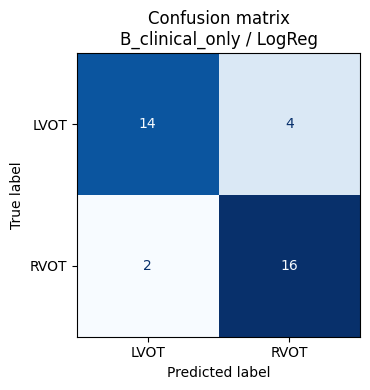

In [18]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title(f"Confusion matrix\n{best_experiment} / {best_model_name}")
plt.tight_layout()
plt.savefig("fig_teknon_confusion_best.png", dpi=150, bbox_inches="tight")
plt.show()


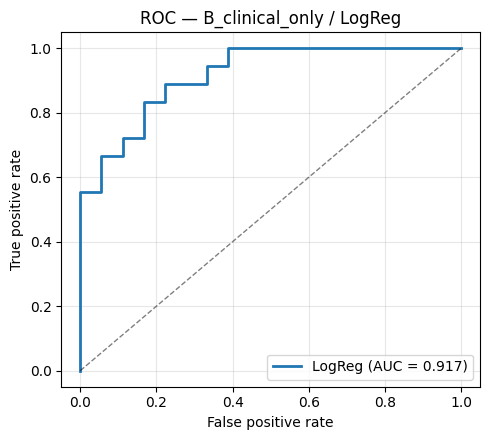

In [19]:
# ROC
fpr, tpr, _ = roc_curve(y_test, y_score_best)
auc = roc_auc_score(y_test, y_score_best)
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.plot(fpr, tpr, lw=2, label=f"{best_model_name} (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"ROC — {best_experiment} / {best_model_name}")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_teknon_roc_best.png", dpi=150, bbox_inches="tight")
plt.show()


## 12. Feature importance — clinical and combined

Two views are useful here:

* **Clinical view (Experiment B's best model).** Are Age, Sex, V3 amplitude and the transition vector the main drivers, as the paper found?
* **Combined view (CV-best model overall).** If the CV-best happens to be a C-experiment, this shows how the QRS-derived feature(s) rank against the clinical ones — the paper reports the QRS prediction is among the top three.

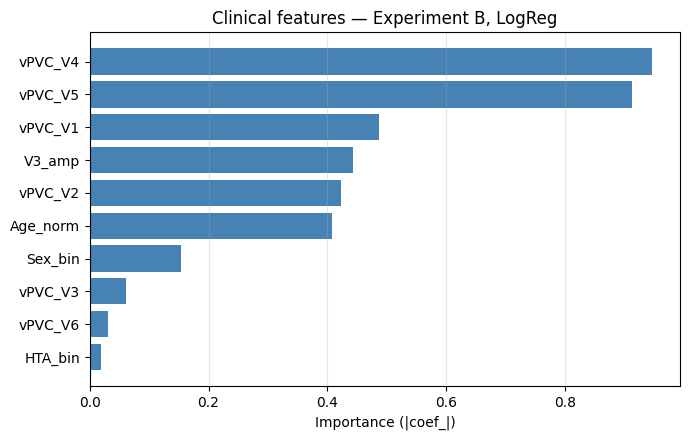

,feature,importance
0,vPVC_V4,0.946902
1,vPVC_V5,0.912890
2,vPVC_V1,0.487871
3,V3_amp,0.444166
4,vPVC_V2,0.423688
5,Age_norm,0.407556
6,Sex_bin,0.153726
7,vPVC_V3,0.061088
8,vPVC_V6,0.030881
9,HTA_bin,0.019273


In [20]:
def get_importance(model, X, y, feature_names):
    """Return non-negative importance scores aligned with feature_names."""
    inner = model.named_steps.get("clf", model) if isinstance(model, Pipeline) else model
    if hasattr(inner, "feature_importances_"):
        imp = np.asarray(inner.feature_importances_, dtype=float)
        kind = "feature_importances_"
    elif hasattr(inner, "coef_"):
        coef = inner.coef_
        imp = np.abs(coef).mean(axis=0) if coef.ndim == 2 else np.abs(coef)
        kind = "|coef_|"
    else:
        r = permutation_importance(model, X, y, n_repeats=20, random_state=RANDOM_STATE,
                                   n_jobs=-1, scoring="balanced_accuracy")
        imp = r.importances_mean.copy(); imp[imp < 0] = 0.0
        kind = "permutation_importance"
    return imp, kind


# --- Best Experiment B model
best_B_model_name = cv_B_df.iloc[0]["model"]
best_B_est, _, X_te_B = fitted[("B_clinical_only", best_B_model_name)]
imp_B, kind_B = get_importance(best_B_est, X_te_B, y_test, CLIN_COLS)
imp_B_df = pd.DataFrame({"feature": CLIN_COLS, "importance": imp_B}) \
             .sort_values("importance", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(imp_B_df["feature"], imp_B_df["importance"], color="steelblue")
ax.set_xlabel(f"Importance ({kind_B})")
ax.set_title(f"Clinical features — Experiment B, {best_B_model_name}")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("fig_teknon_importance_clinical.png", dpi=150, bbox_inches="tight")
plt.show()

imp_B_df.iloc[::-1].reset_index(drop=True)


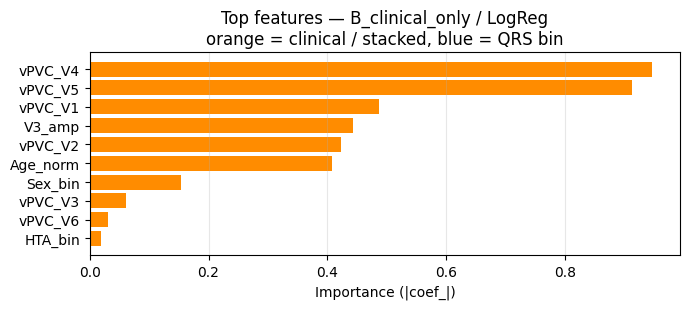

,feature,importance
0,vPVC_V4,0.946902
1,vPVC_V5,0.912890
2,vPVC_V1,0.487871
3,V3_amp,0.444166
4,vPVC_V2,0.423688
5,Age_norm,0.407556
6,Sex_bin,0.153726
7,vPVC_V3,0.061088
8,vPVC_V6,0.030881
9,HTA_bin,0.019273


In [21]:
# --- CV-best model (could be A, B, or any C)
# Build feature_names for whichever experiment was selected
if best_experiment == "A_QRS_only":
    combined_names = qrs_feature_names
elif best_experiment == "B_clinical_only":
    combined_names = CLIN_COLS
elif best_experiment == "C1_clin_plus_pred":
    combined_names = CLIN_COLS + ["QRS_pred"]
elif best_experiment == "C2_clin_plus_proba":
    combined_names = CLIN_COLS + ["QRS_proba"]
elif best_experiment == "C3_clin_plus_qrs":
    combined_names = CLIN_COLS + qrs_feature_names
else:
    raise RuntimeError(best_experiment)

imp_best, kind_best = get_importance(best_est, X_te_best, y_test, combined_names)
imp_best_df = pd.DataFrame({"feature": combined_names, "importance": imp_best}) \
                .sort_values("importance", ascending=False).reset_index(drop=True)

# Show top 20 to keep the chart legible when C.3 was picked
top_k = min(20, len(combined_names))
top_df = imp_best_df.head(top_k).iloc[::-1]

fig, ax = plt.subplots(figsize=(7, max(3, 0.32 * top_k)))
# Colour clinical vs QRS bins differently so the eye can separate them
colors = ["darkorange" if (f in CLIN_COLS or f in ("QRS_pred", "QRS_proba"))
          else "steelblue" for f in top_df["feature"]]
ax.barh(top_df["feature"], top_df["importance"], color=colors)
ax.set_xlabel(f"Importance ({kind_best})")
ax.set_title(f"Top features — {best_experiment} / {best_model_name}\n"
             "orange = clinical / stacked, blue = QRS bin")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("fig_teknon_importance_combined.png", dpi=150, bbox_inches="tight")
plt.show()

imp_best_df.head(top_k)


## 13. SHAP (optional)

If SHAP is available we compute a beeswarm plot. As in the previous notebook, we prefer a tree-based model. If the CV-best isn't a tree we use RandomForest on the same feature set as a complementary explainer.

CV-best model (LogReg) is not tree-based; using RandomForest on the same features as a SHAP-compatible explainer.
Computing SHAP for RandomForest on B_clinical_only...


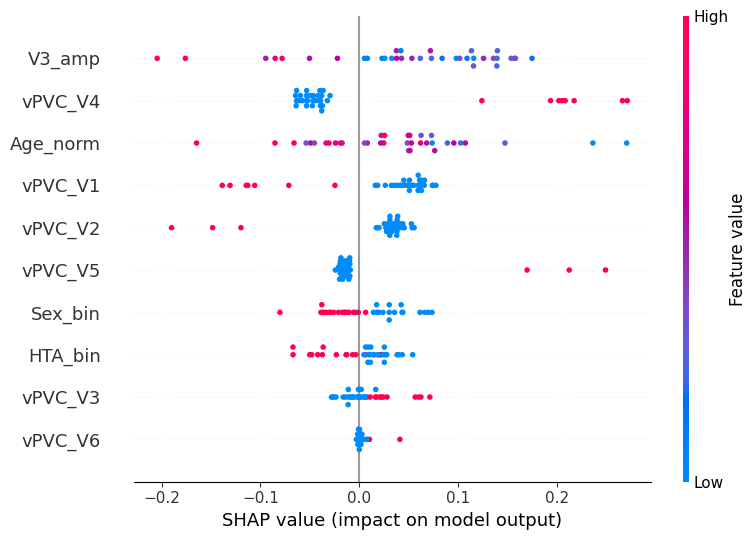

In [22]:
if not SHAP_AVAILABLE:
    print("SHAP is not installed. Skipping SHAP analysis. "
          "Feature/permutation importance is still available above.")
else:
    tree_compatible = {"RandomForest", "GradientBoosting"}
    if best_model_name in tree_compatible:
        shap_model_name = best_model_name
        shap_est = best_est
    else:
        shap_model_name = "RandomForest"
        shap_est, _, _ = fitted[(best_experiment, "RandomForest")]
        print(f"CV-best model ({best_model_name}) is not tree-based; "
              f"using RandomForest on the same features as a SHAP-compatible explainer.")

    print(f"Computing SHAP for {shap_model_name} on {best_experiment}...")
    explainer = shap.TreeExplainer(shap_est)
    sv = explainer.shap_values(X_te_best)
    if isinstance(sv, list):
        sv_pos = sv[1]
    elif isinstance(sv, np.ndarray) and sv.ndim == 3:
        sv_pos = sv[..., 1]
    else:
        sv_pos = sv

    plt.figure()
    shap.summary_plot(sv_pos, X_te_best, feature_names=combined_names,
                      max_display=12, show=False)
    plt.tight_layout()
    plt.savefig("fig_teknon_shap_combined.png", dpi=150, bbox_inches="tight")
    plt.show()


## 14. Comparison with Bocanegra-Pérez et al. (2024)

| Metric | Paper, Experiment B.4 (XGB) | Paper, Experiment C.1 (XGB) | This notebook |
|---|---|---|---|
| Features | NormAge, Sex, HTA, AmpV3, vPTC | B.4 features + binary QRS-pred | (filled in by the cells above) |
| Accuracy | 0.89 | 0.89 | see `E3_teknon_test_results.csv` |
| Balanced accuracy | 0.86 | 0.86 | idem |

**Things to look for in the importance / SHAP plots**

* The paper reports that, on the Teknon cohort, **Age and V3 amplitude** dominate the Gini ranking of B.4; **Age and Sex** dominate the SHAP ranking of C.1; the QRS-model prediction is **always among the top 3**.
* In experiment C, the precordial-transition vector contributes little when the QRS prediction is also present — the paper attributes this to **redundancy** (the transition lead is largely recoverable from the precordial QRS shape that the A model already used).
* If our C.3 (concatenation) wins CV by more than ~3 points over B.4, we are buying performance with interpretability cost; if it ties or loses, the clinical-only model is the more defensible choice.

**Caveats specific to this run**

* The Teknon training pool is 143 patients — small. Expect 5-fold CV folds to be noisy (~28 validation samples each).
* The official test set is 37 patients (14 LVOT, 23 RVOT). One additional misclassification changes accuracy by ~2.7 points.
* For Experiment C we used `cross_val_predict` to avoid leaking the QRS prediction back into its own training set. The paper does not explicitly state how they constructed this feature; if they used in-sample predictions, their reported numbers may be optimistic.


## 15. Save enriched per-patient predictions (CV-best model)

In [23]:
enriched = info_test.copy().reset_index(drop=True)

# Attach the clinical features used by the model so the row tells the full story
enriched = pd.concat(
    [enriched, clin_test_df[CLIN_COLS].reset_index(drop=True)], axis=1
)
enriched["experiment"] = best_experiment
enriched["model"]      = best_model_name
enriched["true_label"] = y_test
enriched["pred_label"] = y_pred_best
enriched["true_class"] = [CLASS_NAMES[c] for c in y_test]
enriched["pred_class"] = [CLASS_NAMES[c] for c in y_pred_best]
enriched["correct"]    = (enriched["true_label"] == enriched["pred_label"]).astype(int)
enriched["score_RVOT"] = y_score_best
enriched["qrs_proba_RVOT"] = qrs_proba_test  # also useful for inspection

enriched.to_csv("E3_teknon_predictions_enriched.csv", index=False)
print("Saved E3_teknon_predictions_enriched.csv, shape:", enriched.shape)
enriched[["patient", "true_class", "pred_class", "correct",
          "score_RVOT", "qrs_proba_RVOT",
          "Age_norm", "Sex_bin", "HTA_bin", "V3_amp"]].head(10)


Saved E3_teknon_predictions_enriched.csv, shape: (36, 40)


,patient,true_class,pred_class,correct,score_RVOT,qrs_proba_RVOT,Age_norm,Sex_bin,HTA_bin,V3_amp
0,patient_145,RVOT,RVOT,1,0.970964,0.753000,0.74,0.0,1.0,1.824
1,patient_146,LVOT,RVOT,0,0.532369,0.551262,0.59,1.0,0.0,2.091
2,patient_147,RVOT,RVOT,1,0.923624,0.882000,0.56,0.0,0.0,5.139
3,patient_148,LVOT,LVOT,1,0.159731,0.172890,0.65,0.0,0.0,3.141
4,patient_149,LVOT,LVOT,1,0.457874,0.140052,0.55,1.0,1.0,2.898
5,patient_150,LVOT,LVOT,1,0.273366,0.272982,0.69,0.0,1.0,4.233
6,patient_151,LVOT,RVOT,0,0.659890,0.918000,0.47,0.0,0.0,2.277
7,patient_152,RVOT,RVOT,1,0.908682,0.835221,0.69,1.0,0.0,1.635
8,patient_153,RVOT,RVOT,1,0.971005,0.516293,0.36,0.0,0.0,1.524
9,patient_154,RVOT,RVOT,1,0.967568,0.941131,0.46,0.0,0.0,1.212


## 16. Per-patient error analysis on the Teknon test

What the headline number — ~82% — *hides* is **which patients** the model gets wrong. This section pulls clinical context (precordial transition, Penela clinical score, SOO subtype) for every test patient and inspects the misclassified ones.

**Questions we want to answer.**

* Are the errors concentrated in a specific SOO subtype (e.g., aortic cusp, RCC/LCC commissure)?
* Do they have **atypical precordial transitions** — LVOT patients whose transition is late (V4-V6), or RVOT patients whose transition is early (V1-V3)?
* Are they **close-call errors** (P(RVOT) ≈ 0.5) or **confident-but-wrong errors**?
* Do their **Penela clinical scores** point the wrong way?


In [24]:
# We already loaded the pkl in §2. Just pull the extra fields not in clin_*_df.
test_pids = info_test["patient_index"].astype(int).to_numpy()
extra = pd.DataFrame({
    "PVC_transition": [pkl["PVC_transition"][p] for p in test_pids],
    "CLINICAL_SCORE": [pkl["CLINICAL_SCORE"][p] for p in test_pids],
    "Age":            [pkl["Age"][p] for p in test_pids],
    "Sex":            [pkl["Sex"][p] for p in test_pids],
    "HTA":            [pkl["HTA"][p] for p in test_pids],
})

# --- Build error table using the CV-best predictions from §11 ---
err = pd.DataFrame({
    "patient":     info_test["patient"].values,
    "true_class":  [CLASS_NAMES[c] for c in y_test],
    "pred_class":  [CLASS_NAMES[c] for c in y_pred_best],
    "P_RVOT":      np.round(y_score_best, 3),
    "SOO_7class":  info_test["SOO_7class"].values,
})
for col in ["PVC_transition", "CLINICAL_SCORE", "Age", "Sex", "HTA"]:
    err[col] = extra[col].values

err["correct"] = err["true_class"] == err["pred_class"]

# Atypical-transition flag: LVOT should transition early (V1-V3), RVOT late (V4-V6)
def _is_atypical(row):
    pvc = row["PVC_transition"]
    if pvc not in ("V1", "V2", "V3", "V4", "V5", "V6"):
        return np.nan
    if row["true_class"] == "LVOT":
        return pvc in ("V4", "V5", "V6")
    return pvc in ("V1", "V2", "V3")

err["atypical_transition"] = err.apply(_is_atypical, axis=1)
err["confidence"] = (np.abs(err["P_RVOT"] - 0.5) * 2).round(3)

n_err = (~err["correct"]).sum()
print(f"Total errors: {n_err}/{len(err)}  ({n_err/len(err)*100:.1f}%)")
print(f"CV-best model: {best_experiment} / {best_model_name}")
print()
print("=== Misclassified patients ===")
err_view = err[~err["correct"]].drop(columns=["correct"]).reset_index(drop=True)
err_view


Total errors: 6/36  (16.7%)
CV-best model: B_clinical_only / LogReg

=== Misclassified patients ===


,patient,true_class,pred_class,P_RVOT,SOO_7class,PVC_transition,CLINICAL_SCORE,Age,Sex,HTA,atypical_transition,confidence
0,patient_146,LVOT,RVOT,0.532,LCC,V3,NaN,NaN,NaN,NaN,False,0.064
1,patient_151,LVOT,RVOT,0.660,LCC,V3,0.0,47.0,Female,No,False,0.320
2,patient_161,RVOT,LVOT,0.450,Septum RVOT,V3,1.0,33.0,Male,No,True,0.100
3,patient_167,RVOT,LVOT,0.404,Septum RVOT,V3,2.0,64.0,Male,No,True,0.192
4,patient_174,LVOT,RVOT,0.900,RCC/LCC Commissure,V4,2.0,59.0,Male,No,True,0.800
5,patient_177,LVOT,RVOT,0.567,RCC,V3,3.0,52.0,Male,Yes,False,0.134


In [25]:
# --- Aggregations ---
print("=== Errors by SOO subtype (7-class) ===")
by_soo = err.groupby("SOO_7class", dropna=False).agg(
    n=("correct", "size"),
    n_errors=("correct", lambda x: (~x).sum()),
)
by_soo["err_rate"] = (by_soo["n_errors"] / by_soo["n"]).round(2)
print(by_soo.sort_values("err_rate", ascending=False))

print("\n=== Errors by precordial transition lead ===")
by_pvc = err.groupby("PVC_transition", dropna=False).agg(
    n=("correct", "size"),
    n_errors=("correct", lambda x: (~x).sum()),
)
by_pvc["err_rate"] = (by_pvc["n_errors"] / by_pvc["n"]).round(2)
print(by_pvc.sort_values("err_rate", ascending=False))

print("\n=== Atypical-transition rate among correct vs errors ===")
atyp = err.dropna(subset=["atypical_transition"])
print(atyp.groupby("correct")["atypical_transition"]
        .agg(n_atypical="sum", n_total="size", rate="mean").round(2))

print("\n=== Penela CLINICAL_SCORE distribution by outcome ===")
print(err.groupby("correct")["CLINICAL_SCORE"].describe().round(2))


=== Errors by SOO subtype (7-class) ===
                     n  n_errors  err_rate
SOO_7class                                
RCC                  2         1      0.50
LCC                  5         2      0.40
RCC/LCC Commissure   3         1      0.33
Septum RVOT          7         2      0.29
Free Wall RVOT      11         0      0.00
Subvalvular LVOT     3         0      0.00
Summit LVOT          5         0      0.00

=== Errors by precordial transition lead ===
                 n  n_errors  err_rate
PVC_transition                        
V3              11         5      0.45
V4               8         1      0.12
V1               7         0      0.00
V2               3         0      0.00
V5               3         0      0.00
V6               3         0      0.00
NaN              1         0      0.00

=== Atypical-transition rate among correct vs errors ===
        n_atypical  n_total      rate
correct                              
False            3        6       0.5
True

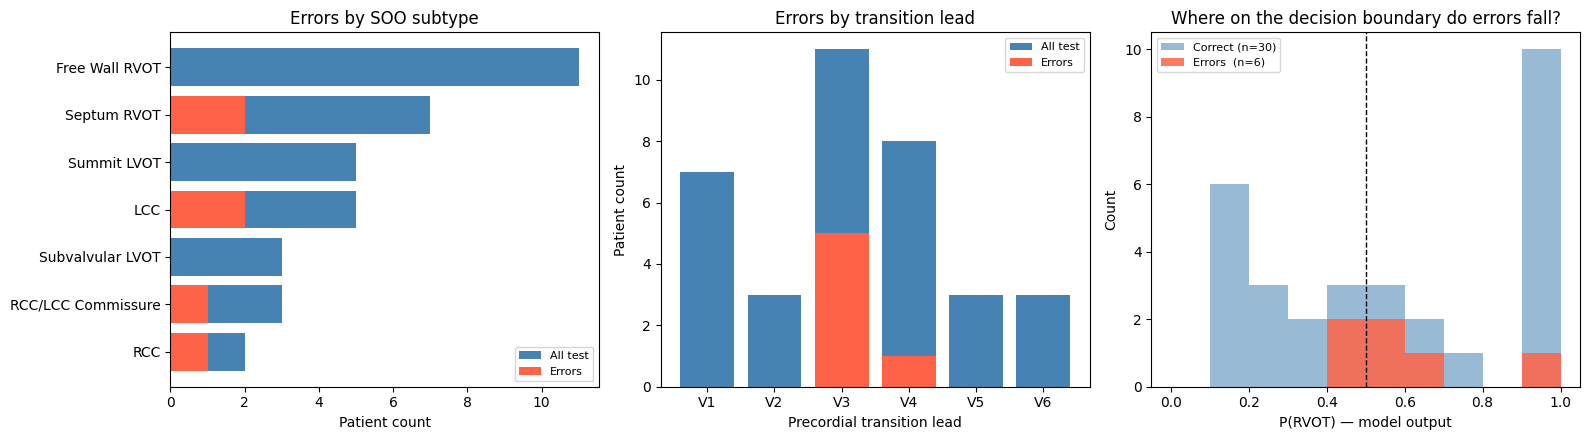

Saved E3_teknon_error_analysis.csv and fig_teknon_error_analysis.png


In [26]:
# --- Visualisation ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) Errors per SOO subtype
soo_df = by_soo.sort_values("n", ascending=True)
ax = axes[0]
ax.barh(soo_df.index.astype(str), soo_df["n"], color="steelblue", label="All test")
ax.barh(soo_df.index.astype(str), soo_df["n_errors"], color="tomato", label="Errors")
ax.set_xlabel("Patient count")
ax.set_title("Errors by SOO subtype")
ax.legend(fontsize=8)

# (b) Errors per PVC transition lead
order = ["V1", "V2", "V3", "V4", "V5", "V6"]
pvc_df = by_pvc.reindex(order).fillna(0)
ax = axes[1]
ax.bar(order, pvc_df["n"], color="steelblue", label="All test")
ax.bar(order, pvc_df["n_errors"], color="tomato", label="Errors")
ax.set_xlabel("Precordial transition lead")
ax.set_ylabel("Patient count")
ax.set_title("Errors by transition lead")
ax.legend(fontsize=8)

# (c) Confidence distribution
ax = axes[2]
ok = err.loc[err["correct"], "P_RVOT"]
ko = err.loc[~err["correct"], "P_RVOT"]
ax.hist(ok, bins=10, range=(0, 1), alpha=0.55, color="steelblue", label=f"Correct (n={len(ok)})")
ax.hist(ko, bins=10, range=(0, 1), alpha=0.85, color="tomato",   label=f"Errors  (n={len(ko)})")
ax.axvline(0.5, color="black", ls="--", lw=1)
ax.set_xlabel("P(RVOT) — model output")
ax.set_ylabel("Count")
ax.set_title("Where on the decision boundary do errors fall?")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig_teknon_error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

err.to_csv("E3_teknon_error_analysis.csv", index=False)
print("Saved E3_teknon_error_analysis.csv and fig_teknon_error_analysis.png")


**How to read this when presenting.**

* *Atypical-transition rate among errors > among correct* → the model is failing exactly where the cardiologist's rule of thumb (LVOT ↔ early transition, RVOT ↔ late) breaks. That isn't a model weakness so much as a **fundamental ambiguity in the ECG itself** — and it justifies adding clinical data on top, which is exactly what this notebook does.
* *Errors clustered near P(RVOT) = 0.5* → low-confidence borderline cases. A "second opinion" / abstain workflow could flag these for the clinician.
* *Errors with high confidence but wrong* → more concerning. For these, looking back at the §3 raw-signal plots vs. their individual QRS reveals what makes them atypical.
* *Discordant Penela clinical score* → if a misclassified patient also has a Penela score pointing the wrong way, that means **both** the QRS and the clinical-rule prediction failed for the same patient — an irreducibly hard case.


## 17. Summary

This notebook replicates **Experiments B and C** from Bocanegra-Pérez et al. (2024) on a *Teknon-only* slice of the corrected pool (143 train, 37 test). Three families are compared head-to-head: pure QRS (A), pure clinical (B), and combinations (C.1/C.2 paper-style stacking, C.3 concatenation).

**Artifacts written by this notebook**

* `E3_teknon_cv_results.csv` — 5-fold CV results for every (experiment, model)
* `E3_teknon_test_results.csv` — final Teknon-test results for every (experiment, model)
* `E3_teknon_predictions_enriched.csv` — per-patient predictions of the CV-best model, with clinical features attached
* `E3_teknon_error_analysis.csv` — per-patient error table with full clinical context
* `fig_qualitative_qrs_teknon.png` — mean ± SD QRS overlays per class on Teknon training (§3)
* `fig_teknon_confusion_best.png`, `fig_teknon_roc_best.png`
* `fig_teknon_importance_clinical.png`, `fig_teknon_importance_combined.png`
* `fig_teknon_shap_combined.png` (only if SHAP is installed)
* `fig_teknon_error_analysis.png` — error analysis multi-panel figure

Model selection used **CV balanced accuracy only**; the Teknon test set was evaluated once at the end. For stacked models the QRS-derived feature was generated with `cross_val_predict` so that no training sample ever saw a QRS prediction conditioned on itself.